In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 这两句作用为防止中文乱码
plt.rcParams['axes.unicode_minus'] = False
data = pd.read_csv("F:/AAAAAAAAAAAAAAAAAAAAA/Senior/subject/数据挖掘/实验八/LCIS.csv")
data = data.sample(10000)  # 抽取样例10000个
data.reset_index(inplace=True)  # 重置索引

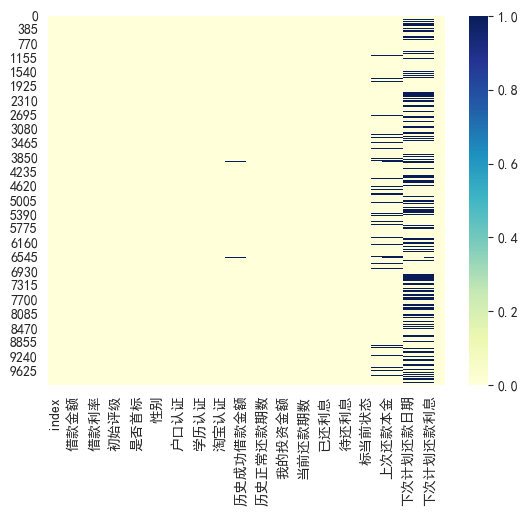

In [2]:
sns.heatmap(data.isnull(), cmap="YlGnBu")
plt.show()
# 深颜色的横线就代表缺失值。因为数据中我们使用了isnull()方法，若判断为空，则值为1，否则为#0；从图中，我们可以看到，最后几个属性的缺失值最多，其他的几乎没有。
# 优点：能够清楚看到哪些地方有缺失，缺失程度。

In [3]:
# 使用info()查看缺失值
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 38 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   index       10000 non-null  int64  
 1   ListingId   10000 non-null  int64  
 2   借款金额        10000 non-null  int64  
 3   借款期限        10000 non-null  int64  
 4   借款利率        10000 non-null  float64
 5   借款成功日期      10000 non-null  object 
 6   初始评级        10000 non-null  object 
 7   借款类型        10000 non-null  object 
 8   是否首标        10000 non-null  object 
 9   年龄          10000 non-null  int64  
 10  性别          10000 non-null  object 
 11  手机认证        10000 non-null  object 
 12  户口认证        10000 non-null  object 
 13  视频认证        10000 non-null  object 
 14  学历认证        10000 non-null  object 
 15  征信认证        10000 non-null  object 
 16  淘宝认证        10000 non-null  object 
 17  历史成功借款次数    9945 non-null   float64
 18  历史成功借款金额    9945 non-null   float64
 19  总待还本金       10000 non-null

In [4]:
# 使用apply()统计缺失率
count_missing = data.apply(lambda x: '{}%'.format(round(100*sum(x.isnull())/len(x), 2)))
print(count_missing)
# 通过这样的方法，可以统计出每一个属性的缺失率。
# 优点：百分比显示缺失率更加直观，对于缺失率高的属性，可以考虑删除。

index           0.0%
ListingId       0.0%
借款金额            0.0%
借款期限            0.0%
借款利率            0.0%
借款成功日期          0.0%
初始评级            0.0%
借款类型            0.0%
是否首标            0.0%
年龄              0.0%
性别              0.0%
手机认证            0.0%
户口认证            0.0%
视频认证            0.0%
学历认证            0.0%
征信认证            0.0%
淘宝认证            0.0%
历史成功借款次数       0.55%
历史成功借款金额       0.55%
总待还本金           0.0%
历史正常还款期数        0.0%
历史逾期还款期数        0.0%
我的投资金额          0.0%
当前到期期数          0.0%
当前还款期数          0.0%
已还本金            0.0%
已还利息            0.0%
待还本金            0.0%
待还利息            0.0%
标当前逾期天数         0.0%
标当前状态           0.0%
上次还款日期         7.28%
上次还款本金         7.82%
上次还款利息         7.82%
下次计划还款日期      37.47%
下次计划还款本金      37.47%
下次计划还款利息      37.96%
recorddate     0.17%
dtype: object


In [5]:
# 缺失值处理
# 单行数据删除
data.dropna(inplace=True)
# 该方法将存在缺失值的数据全部删除，这里省略axis=0，因为axis默认为0.

In [6]:
# 整列属性删除
data.dropna(inplace=True, axis=1)
# 该方法将存在缺失值的属性删除

In [7]:
data

,index,ListingId,借款金额,借款期限,借款利率,借款成功日期,初始评级,借款类型,是否首标,年龄,...,待还利息,标当前逾期天数,标当前状态,上次还款日期,上次还款本金,上次还款利息,下次计划还款日期,下次计划还款本金,下次计划还款利息,recorddate
1,70405,22020851,9810,12,20.0,2016/10/13,C,其他,否,31,...,3.05,0,正常还款中,2017/2/11,4.64,0.74,2017/3/13,4.70,0.67,2017/2/28
2,110949,17587992,2050,12,22.0,2016/8/13,C,普通,否,25,...,3.96,0,正常还款中,2016/10/15,4.29,0.86,2016/12/13,4.37,0.77,2016/10/31
3,178564,19024507,2100,12,22.0,2016/9/2,C,其他,否,37,...,4.82,0,正常还款中,2016/10/31,4.22,0.93,2016/12/2,4.29,0.86,2016/10/31
4,83768,10084441,7000,12,20.0,2016/3/25,C,APP闪电,是,28,...,0.40,0,正常还款中,2016/12/29,4.33,0.30,2017/1/25,4.40,0.23,2016/12/31
5,167526,21560823,9600,9,18.0,2016/10/18,B,普通,是,21,...,1.51,0,正常还款中,2017/2/16,6.35,0.58,2017/3/18,6.44,0.50,2017/2/28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,197591,16719415,2168,12,22.0,2016/7/30,C,普通,否,22,...,3.61,0,正常还款中,2016/10/31,3.90,0.78,2016/11/30,3.98,0.70,2016/10/31
9992,149712,11698644,2229,12,22.0,2016/5/1,D,其他,否,22,...,2.29,0,正常还款中,2016/9/14,4.20,0.66,2016/11/1,4.28,0.58,2016/9/30
9995,126186,16188441,5000,10,20.0,2016/7/22,C,普通,否,24,...,0.88,0,正常还款中,2016/12/15,5.04,0.43,2017/2/22,5.12,0.35,2016/12/31
9997,33362,14868762,6968,12,18.0,2016/7/1,B,APP闪电,否,27,...,1.84,0,正常还款中,2016/12/3,4.07,0.51,2017/1/1,4.13,0.46,2016/12/31


In [8]:
# 异常检测
# 均值标准差异常值检测
# 此方法公式是：均值±2x标准差
# 数值不在区间【均值-2x标准差，均值+2x标准差】的判定为异常值。
datamean = data['下次计划还款利息'].mean()#均值
datastd = data['下次计划还款利息'].std()#标准差
topdata = datamean+2*datastd#上限
bottomdata = datamean-2*datastd#下限
countdata = data['下次计划还款利息'].between(left=bottomdata, right=topdata)
# 统计异常值和非异常值数量
print(countdata.value_counts())

下次计划还款利息
True     5344
False     132
Name: count, dtype: int64


In [9]:
# 上下四分位和中位差异常值检测
# 此方法公式：上（下）四分位±1.5x中位差
# 正常值区间位：【下四分位-1.5x中位差,上四分位+1.5x中位差】
mediandata = data['下次计划还款利息'].quantile(0.75)-data['下次计划还款利息'].quantile(0.25)
topdata = data['下次计划还款利息'].quantile(0.75)+1.5*mediandata
bottomdata = data['下次计划还款利息'].quantile(0.25)-1.5*mediandata
countdata = data['下次计划还款利息'].between(left=bottomdata, right=topdata)
# 统计异常值和非异常值数量
print(countdata.value_counts())

下次计划还款利息
True     5356
False     120
Name: count, dtype: int64


In [12]:
# 异常值删除
# 异常值删除操作需要两步，第一步是判断，第二步删除
mediandata = data['下次计划还款利息'].quantile(0.75)-data['下次计划还款利息'].quantile(0.25)
topdata = data['下次计划还款利息'].quantile(0.75)+1.5*mediandata
bottomdata = data['下次计划还款利息'].quantile(0.25)-1.5*mediandata
countdata = data['下次计划还款利息'].between(left=bottomdata, right=topdata)
# 取出异常值索引
index_list = data[countdata==False].index.tolist()
data['下次计划还款利息'].drop(labels=index_list, inplace=True)
data

,index,ListingId,借款金额,借款期限,借款利率,借款成功日期,初始评级,借款类型,是否首标,年龄,...,待还利息,标当前逾期天数,标当前状态,上次还款日期,上次还款本金,上次还款利息,下次计划还款日期,下次计划还款本金,下次计划还款利息,recorddate
1,70405,22020851,9810,12,20.0,2016/10/13,C,其他,否,31,...,3.05,0,正常还款中,2017/2/11,4.64,0.74,2017/3/13,4.70,0.67,2017/2/28
2,110949,17587992,2050,12,22.0,2016/8/13,C,普通,否,25,...,3.96,0,正常还款中,2016/10/15,4.29,0.86,2016/12/13,4.37,0.77,2016/10/31
3,178564,19024507,2100,12,22.0,2016/9/2,C,其他,否,37,...,4.82,0,正常还款中,2016/10/31,4.22,0.93,2016/12/2,4.29,0.86,2016/10/31
4,83768,10084441,7000,12,20.0,2016/3/25,C,APP闪电,是,28,...,0.40,0,正常还款中,2016/12/29,4.33,0.30,2017/1/25,4.40,0.23,2016/12/31
5,167526,21560823,9600,9,18.0,2016/10/18,B,普通,是,21,...,1.51,0,正常还款中,2017/2/16,6.35,0.58,2017/3/18,6.44,0.50,2017/2/28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,197591,16719415,2168,12,22.0,2016/7/30,C,普通,否,22,...,3.61,0,正常还款中,2016/10/31,3.90,0.78,2016/11/30,3.98,0.70,2016/10/31
9992,149712,11698644,2229,12,22.0,2016/5/1,D,其他,否,22,...,2.29,0,正常还款中,2016/9/14,4.20,0.66,2016/11/1,4.28,0.58,2016/9/30
9995,126186,16188441,5000,10,20.0,2016/7/22,C,普通,否,24,...,0.88,0,正常还款中,2016/12/15,5.04,0.43,2017/2/22,5.12,0.35,2016/12/31
9997,33362,14868762,6968,12,18.0,2016/7/1,B,APP闪电,否,27,...,1.84,0,正常还款中,2016/12/3,4.07,0.51,2017/1/1,4.13,0.46,2016/12/31


In [13]:
# 异常值重写
# 检测完异常值之后，除了删除数据之外，我们做的最多的就是重写异常值。

# 使用数据的最大值重写：
mediandata = data['下次计划还款利息'].quantile(0.75)-data['下次计划还款利息'].quantile(0.25)
topdata = data['下次计划还款利息'].quantile(0.75)+1.5*mediandata
bottomdata = data['下次计划还款利息'].quantile(0.25)-1.5*mediandata
countdata = data['下次计划还款利息'].between(left=bottomdata, right=topdata)
index_list = data[countdata==False].index.tolist()
data.loc[index_list, '下次计划还款利息'] = data[countdata]['下次计划还款利息'].max()#
data.loc[index_list, '下次计划还款利息'] = data[countdata]['下次计划还款利息'].min()#
data.loc[index_list, '下次计划还款利息'] = -1#特殊值填充
data

,index,ListingId,借款金额,借款期限,借款利率,借款成功日期,初始评级,借款类型,是否首标,年龄,...,待还利息,标当前逾期天数,标当前状态,上次还款日期,上次还款本金,上次还款利息,下次计划还款日期,下次计划还款本金,下次计划还款利息,recorddate
1,70405,22020851,9810,12,20.0,2016/10/13,C,其他,否,31,...,3.05,0,正常还款中,2017/2/11,4.64,0.74,2017/3/13,4.70,0.67,2017/2/28
2,110949,17587992,2050,12,22.0,2016/8/13,C,普通,否,25,...,3.96,0,正常还款中,2016/10/15,4.29,0.86,2016/12/13,4.37,0.77,2016/10/31
3,178564,19024507,2100,12,22.0,2016/9/2,C,其他,否,37,...,4.82,0,正常还款中,2016/10/31,4.22,0.93,2016/12/2,4.29,0.86,2016/10/31
4,83768,10084441,7000,12,20.0,2016/3/25,C,APP闪电,是,28,...,0.40,0,正常还款中,2016/12/29,4.33,0.30,2017/1/25,4.40,0.23,2016/12/31
5,167526,21560823,9600,9,18.0,2016/10/18,B,普通,是,21,...,1.51,0,正常还款中,2017/2/16,6.35,0.58,2017/3/18,6.44,0.50,2017/2/28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,197591,16719415,2168,12,22.0,2016/7/30,C,普通,否,22,...,3.61,0,正常还款中,2016/10/31,3.90,0.78,2016/11/30,3.98,0.70,2016/10/31
9992,149712,11698644,2229,12,22.0,2016/5/1,D,其他,否,22,...,2.29,0,正常还款中,2016/9/14,4.20,0.66,2016/11/1,4.28,0.58,2016/9/30
9995,126186,16188441,5000,10,20.0,2016/7/22,C,普通,否,24,...,0.88,0,正常还款中,2016/12/15,5.04,0.43,2017/2/22,5.12,0.35,2016/12/31
9997,33362,14868762,6968,12,18.0,2016/7/1,B,APP闪电,否,27,...,1.84,0,正常还款中,2016/12/3,4.07,0.51,2017/1/1,4.13,0.46,2016/12/31
